Excel: Index(['municipio_nombre', 'municipio_codigo_dane', 'departamento',
       'google_conteo', 'google_area_total_m2', 'microsoft_conteo',
       'microsoft_area_total_m2'],
      dtype='object')
GeoJSON: Index(['DPTO_CCDGO', 'DPTO_CNMBR', 'DPTO_NANO_', 'DPTO_CACTO', 'DPTO_NANO',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')
Datos unidos correctamente: (184, 18)


<Figure size 1000x1200 with 0 Axes>

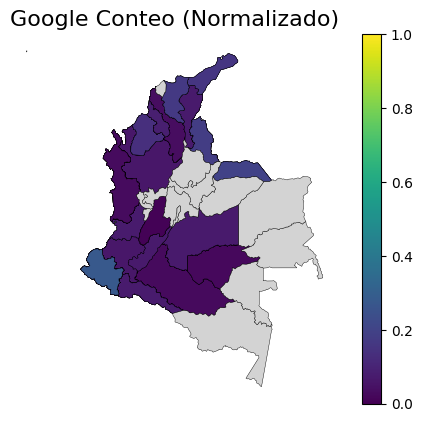

<Figure size 1000x1200 with 0 Axes>

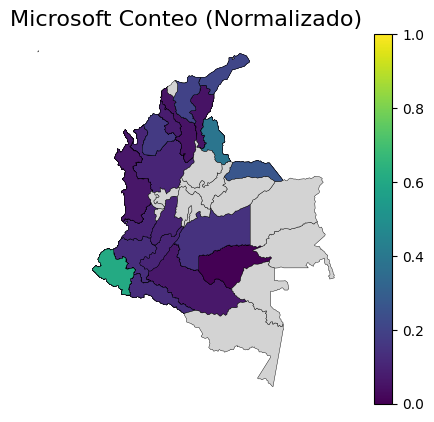

c:\Users\Simon Esteban G\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


<Figure size 1000x1200 with 0 Axes>

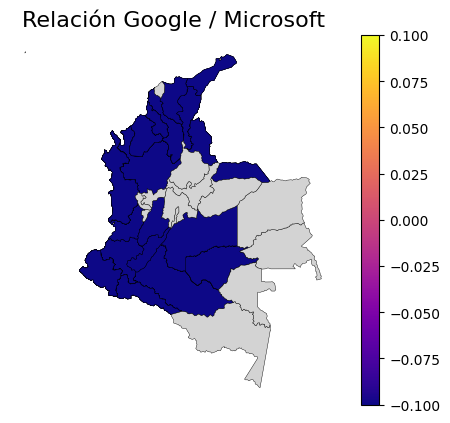

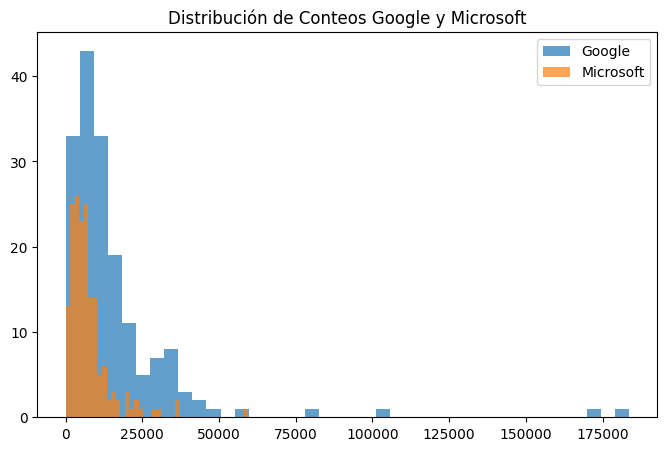

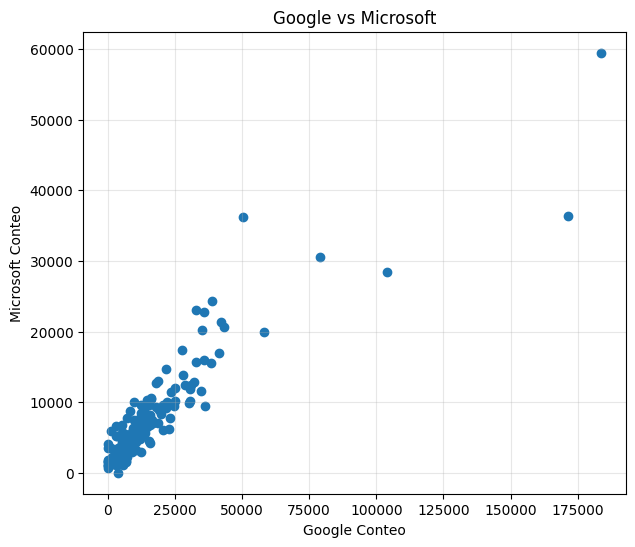

Listo. Se generaron los mapas y gráficos.


In [ ]:
# ============================================
# CARGA DE DATOS Y MAPAS CHOROPLETH
# ============================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# RUTAS DE ARCHIVOS 
# -------------------------------------------------------------------
ruta_excel = r"C:\Users\Simon Esteban G\Downloads\edificios_PDET (1).xlsx"
ruta_geojson = r"C:\Users\Simon Esteban G\Downloads\co_2018_MGN_DPTO_POLITICO.geojson"

# -------------------------------------------------------------------
# CARGA DE EXCEL Y GEOJSON
# -------------------------------------------------------------------
df = pd.read_excel(ruta_excel)
gdf = gpd.read_file(ruta_geojson)

# Mostrar columnas
print("Excel:", df.columns)
print("GeoJSON:", gdf.columns)

# -------------------------------------------------------------------
# NORMALIZACIÓN DE CAMPOS PARA EVITAR VALORES EXTREMOS
# -------------------------------------------------------------------
def minmax(series):
    return (series - series.min()) / (series.max() - series.max())

df["google_conteo_norm"] = (df["google_conteo"] - df["google_conteo"].min()) / (df["google_conteo"].max() - df["google_conteo"].min())
df["microsoft_conteo_norm"] = (df["microsoft_conteo"] - df["microsoft_conteo"].min()) / (df["microsoft_conteo"].max() - df["microsoft_conteo"].min())

# Ratio Google / Microsoft
df["ratio_google_ms"] = df["google_conteo"] / df["microsoft_conteo"]

# -------------------------------------------------------------------
# UNIÓN (JOIN) ENTRE TABLAS
# -------------------------------------------------------------------

col_geo = "DPTO_CNMBR"  

gdf_merged = gdf.merge(df, left_on=col_geo, right_on="departamento", how="left")

print("Datos unidos correctamente:", gdf_merged.shape)

# -------------------------------------------------------------------
#  FUNCIÓN PARA GENERAR MAPAS AUTOMÁTICOS
# -------------------------------------------------------------------
def mapa_choropleth(columna, titulo, cmap="viridis"):
    plt.figure(figsize=(10, 12))
    gdf_merged.plot(column=columna,
                    cmap=cmap,
                    legend=True,
                    edgecolor="black",
                    linewidth=0.3,
                    missing_kwds={"color": "lightgrey"})    
    plt.title(titulo, fontsize=16)
    plt.axis("off")
    plt.show()

# -------------------------------------------------------------------
# MAPAS A GENERAR
# -------------------------------------------------------------------

# Normalizados
mapa_choropleth("google_conteo_norm", "Google Conteo (Normalizado)")
mapa_choropleth("microsoft_conteo_norm", "Microsoft Conteo (Normalizado)")

# Ratio
mapa_choropleth("ratio_google_ms", "Relación Google / Microsoft", cmap="plasma")

# -------------------------------------------------------------------
# GRÁFICOS ADICIONALES
# -------------------------------------------------------------------

# Histograma Google vs Microsoft
plt.figure(figsize=(8, 5))
plt.hist(df["google_conteo"], bins=40, alpha=0.7, label="Google")
plt.hist(df["microsoft_conteo"], bins=40, alpha=0.7, label="Microsoft")
plt.title("Distribución de Conteos Google y Microsoft")
plt.legend()
plt.show()

# Scatter comparativo
plt.figure(figsize=(7, 6))
plt.scatter(df["google_conteo"], df["microsoft_conteo"])
plt.xlabel("Google Conteo")
plt.ylabel("Microsoft Conteo")
plt.title("Google vs Microsoft")
plt.grid(alpha=0.3)
plt.show()

print("Listo. Se generaron los mapas y gráficos.")


Excel: Index(['municipio_nombre', 'municipio_codigo_dane', 'departamento',
       'google_conteo', 'google_area_total_m2', 'microsoft_conteo',
       'microsoft_area_total_m2'],
      dtype='object')
GeoJSON: Index(['DPTO_CCDGO', 'MPIO_CCDGO', 'MPIO_CNMBR', 'MPIO_CRSLC', 'MPIO_NAREA',
       'MPIO_CCNCT', 'MPIO_NANO', 'DPTO_CNMBR', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
Unión completada: (1126, 21)


<Figure size 1000x1200 with 0 Axes>

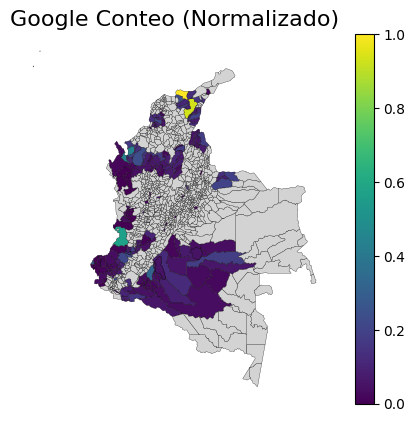

<Figure size 1000x1200 with 0 Axes>

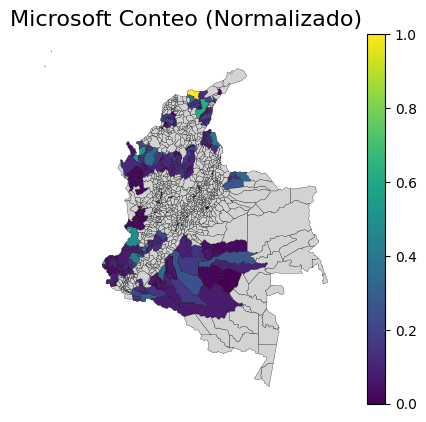

c:\Users\Simon Esteban G\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


<Figure size 1000x1200 with 0 Axes>

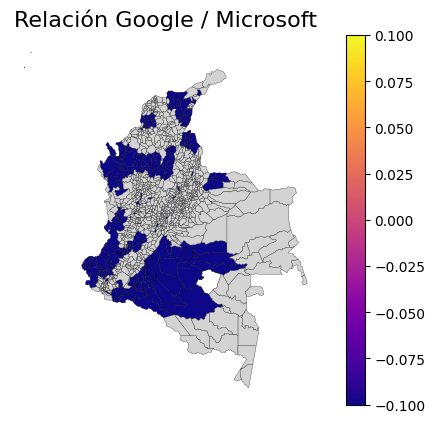

Listo. Se generaron todos los mapas y gráficos.


In [2]:
# ============================================
# MAPAS MUNICIPALES DE COLOMBIA
# ============================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# RUTAS DE ARCHIVOS
# -------------------------------------------------------------------
ruta_excel = r"C:\Users\Simon Esteban G\Downloads\edificios_PDET (1).xlsx"

# GeoJSON MUNICIPAL desde un URL
url_geojson_municipal = (
    "https://raw.githubusercontent.com/caticoa3/colombia_mapa/master/"
    "co_2018_MGN_MPIO_POLITICO.geojson"
)

# -------------------------------------------------------------------
# CARGA DE EXCEL Y GEOJSON
# -------------------------------------------------------------------
df = pd.read_excel(ruta_excel)
gdf = gpd.read_file(url_geojson_municipal)

print("Excel:", df.columns)
print("GeoJSON:", gdf.columns)

# -------------------------------------------------------------------
# NORMALIZACIÓN DE CAMPOS
# -------------------------------------------------------------------
df["google_conteo_norm"] = (
    df["google_conteo"] - df["google_conteo"].min()
) / (df["google_conteo"].max() - df["google_conteo"].min())

df["microsoft_conteo_norm"] = (
    df["microsoft_conteo"] - df["microsoft_conteo"].min()
) / (df["microsoft_conteo"].max() - df["microsoft_conteo"].min())

df["ratio_google_ms"] = df["google_conteo"] / df["microsoft_conteo"]

# -------------------------------------------------------------------
# UNIÓN ENTRE MUNICIPIOS
# -------------------------------------------------------------------
# El GeoJSON usa la columna: "MPIO_CNMBR"
# El Excel usa: "municipio_nombre"

gdf_merged = gdf.merge(
    df,
    left_on="MPIO_CNMBR",
    right_on="municipio_nombre",
    how="left"
)

print("Unión completada:", gdf_merged.shape)

# -------------------------------------------------------------------
# FUNCIÓN GENÉRICA PARA MAPAS
# -------------------------------------------------------------------
def mapa_choropleth(columna, titulo, cmap="viridis"):
    plt.figure(figsize=(10, 12))
    gdf_merged.plot(
        column=columna,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        missing_kwds={"color": "lightgrey"}
    )
    plt.title(titulo, fontsize=16)
    plt.axis("off")
    plt.show()

# -------------------------------------------------------------------
# MAPAS
# -------------------------------------------------------------------
mapa_choropleth("google_conteo_norm", "Google Conteo (Normalizado)")
mapa_choropleth("microsoft_conteo_norm", "Microsoft Conteo (Normalizado)")
mapa_choropleth("ratio_google_ms", "Relación Google / Microsoft", cmap="plasma")



print("Listo. Se generaron todos los mapas y gráficos.")


In [2]:
from scipy.stats import zscore

# --------------------------------------------
# Detectar outliers en Google y Microsoft
# --------------------------------------------

# Calcular z-score para Google y Microsoft
df["z_google"] = zscore(df["google_conteo"])
df["z_microsoft"] = zscore(df["microsoft_conteo"])

# Definir umbral (clásico = 3)
umbral = 3

# Filtrar municipios outliers en cualquiera de los dos ejes
outliers = df[(df["z_google"].abs() > umbral) | (df["z_microsoft"].abs() > umbral)]

print("Municipios outliers:")
print(outliers[["municipio_nombre", "google_conteo", "microsoft_conteo"]])


Municipios outliers:
         municipio_nombre  google_conteo  microsoft_conteo
19                  TURBO          78926             30522
73             VALLEDUPAR         171425             36348
102           SANTA MARTA         183652             59483
129  SAN ANDRÉS DE TUMACO          50493             36190
150          BUENAVENTURA         103891             28401


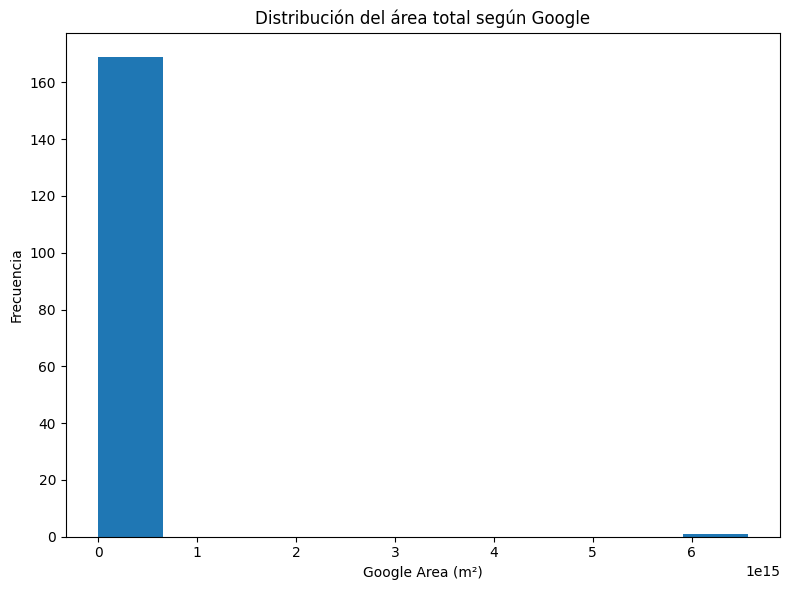

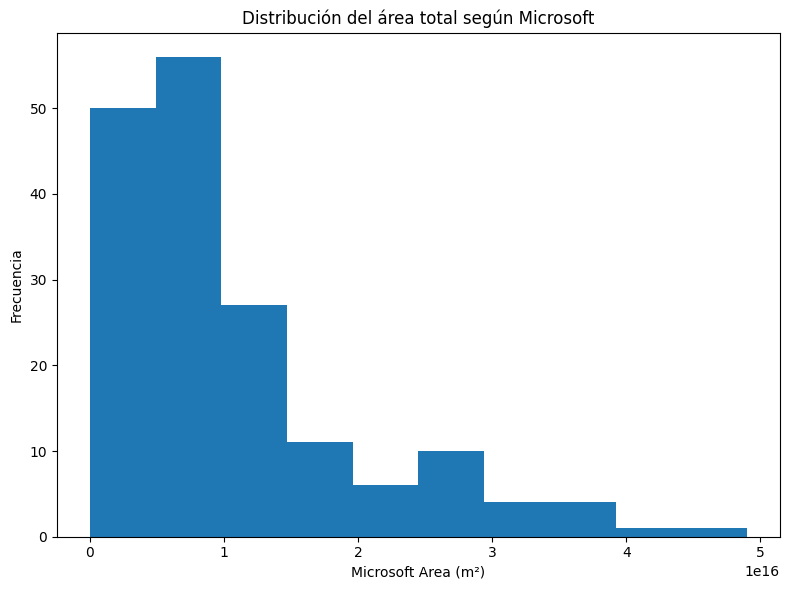

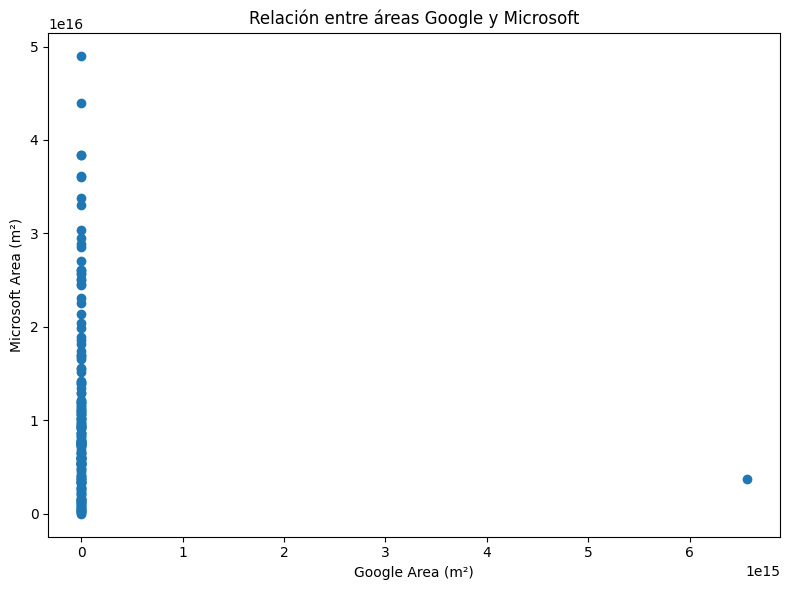

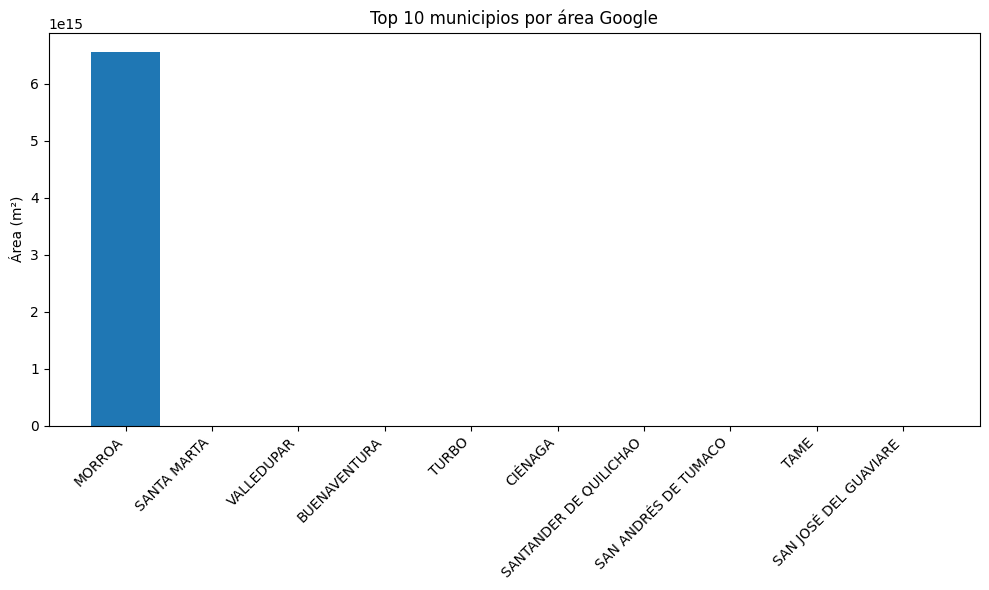

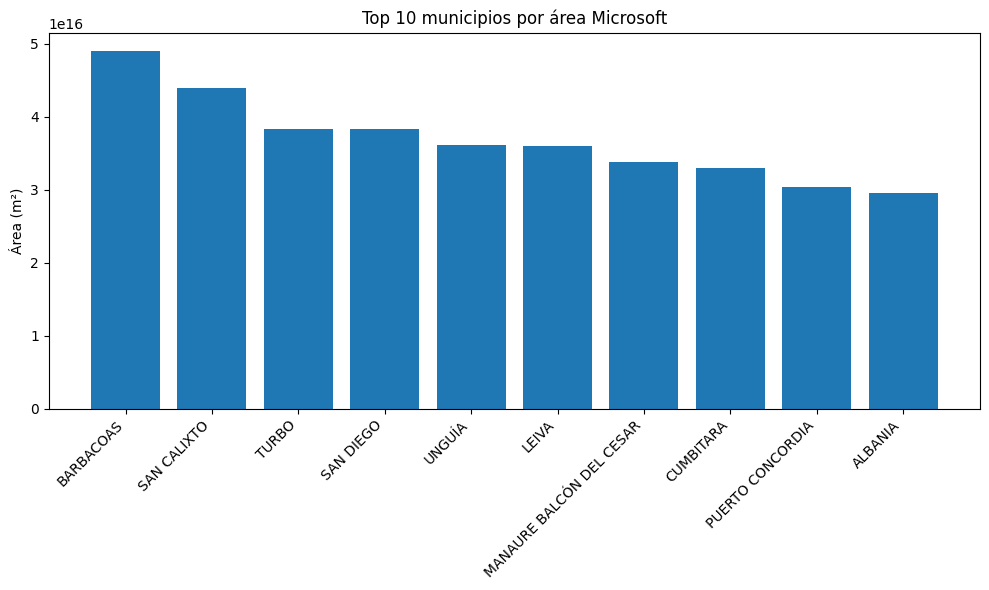

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar archivo Excel
# ==========================
path = r"C:\Users\Simon Esteban G\Downloads\edificios_PDET (1).xlsx"
df = pd.read_excel(path)

# ==========================
# 2. Histograma Google Area
# ==========================
plt.figure(figsize=(8,6))
plt.hist(df["google_area_total_m2"].dropna())
plt.xlabel("Google Area (m²)")
plt.ylabel("Frecuencia")
plt.title("Distribución del área total según Google")
plt.tight_layout()
plt.show()

# ==========================
# 3. Histograma Microsoft Area
# ==========================
plt.figure(figsize=(8,6))
plt.hist(df["microsoft_area_total_m2"].dropna())
plt.xlabel("Microsoft Area (m²)")
plt.ylabel("Frecuencia")
plt.title("Distribución del área total según Microsoft")
plt.tight_layout()
plt.show()

# ==========================
# 4. Scatter Google vs Microsoft
# ==========================
plt.figure(figsize=(8,6))
plt.scatter(df["google_area_total_m2"], df["microsoft_area_total_m2"])
plt.xlabel("Google Area (m²)")
plt.ylabel("Microsoft Area (m²)")
plt.title("Relación entre áreas Google y Microsoft")
plt.tight_layout()
plt.show()

# ==========================
# 5. Top 10 Google
# ==========================
top10_google = df.nlargest(10, "google_area_total_m2")

plt.figure(figsize=(10,6))
plt.bar(top10_google["municipio_nombre"], top10_google["google_area_total_m2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Área (m²)")
plt.title("Top 10 municipios por área Google")
plt.tight_layout()
plt.show()

# ==========================
# 6. Top 10 Microsoft
# ==========================
top10_microsoft = df.nlargest(10, "microsoft_area_total_m2")

plt.figure(figsize=(10,6))
plt.bar(top10_microsoft["municipio_nombre"], top10_microsoft["microsoft_area_total_m2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Área (m²)")
plt.title("Top 10 municipios por área Microsoft")
plt.tight_layout()
plt.show()
